In [1]:
DATA_DIR = "/kaggle/input/datasets/iftekharuddin27/capstone-datasets" 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

In [3]:
try:
    from wordcloud import WordCloud
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'wordcloud', '-q'])
    from wordcloud import WordCloud
 
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
 
print("All imports successful!")

All imports successful!


In [4]:
df_en = pd.read_csv(f"{DATA_DIR}/English_combined_dataset.csv")
df_bn = pd.read_csv(f"{DATA_DIR}/bangla_hate_pool.csv")
 
CLASS_NAMES = {0: 'Non-hateful', 1: 'Hateful', 2: 'Sarcastic'}
 
print("=" * 60)
print("ENGLISH DATASET")
print("=" * 60)
print(f"Shape: {df_en.shape}")
print(f"Columns: {list(df_en.columns)}")
print(f"Null values:\n{df_en.isnull().sum()}")
print(f"\nClass Distribution:")
for cls, count in df_en['class'].value_counts().sort_index().items():
    pct = count / len(df_en) * 100
    print(f"  Class {cls} ({CLASS_NAMES[cls]}): {count:,} ({pct:.1f}%)")
 
print("\n" + "=" * 60)
print("BANGLA DATASET")
print("=" * 60)
print(f"Shape: {df_bn.shape}")
print(f"Columns: {list(df_bn.columns)}")
print(f"Null values:\n{df_bn.isnull().sum()}")
print(f"\nLabel Distribution:")
for cls, count in df_bn['label'].value_counts().sort_index().items():
    pct = count / len(df_bn) * 100
    print(f"  Label {cls} ({CLASS_NAMES[cls]}): {count:,} ({pct:.1f}%)")
 
print(f"\nBangla Sources: {df_bn['source'].unique().tolist()}")

ENGLISH DATASET
Shape: (104737, 2)
Columns: ['text', 'class']
Null values:
text     0
class    0
dtype: int64

Class Distribution:
  Class 0 (Non-hateful): 34,794 (33.2%)
  Class 1 (Hateful): 35,102 (33.5%)
  Class 2 (Sarcastic): 34,841 (33.3%)

BANGLA DATASET
Shape: (83992, 3)
Columns: ['text', 'label', 'source']
Null values:
text      0
label     0
source    0
dtype: int64

Label Distribution:
  Label 0 (Non-hateful): 41,497 (49.4%)
  Label 1 (Hateful): 25,669 (30.6%)
  Label 2 (Sarcastic): 16,826 (20.0%)

Bangla Sources: ['ALERT', 'BD_SHS', 'BenSarc', 'BanglaSarc3', 'BIDWESH']


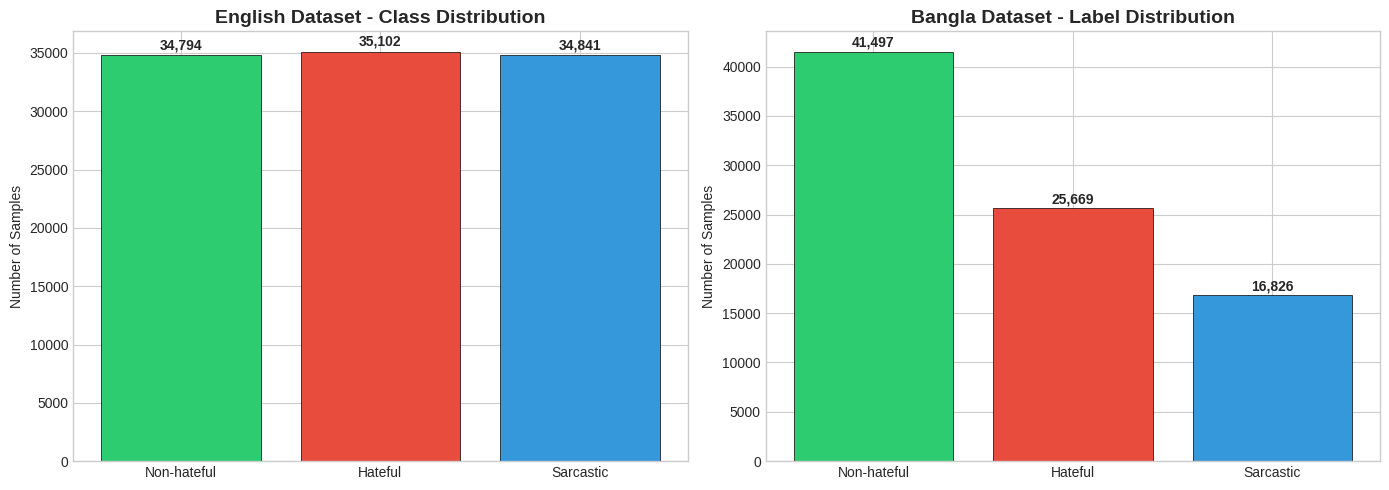


Key Observation:
- English dataset is BALANCED (each class ~34-35K)
- Bangla dataset is IMBALANCED (Non-hateful: 41K, Hateful: 25K, Sarcastic: 16K)
- This imbalance needs to be handled in Phase 3


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# English
en_counts = df_en['class'].value_counts().sort_index()
bars1 = axes[0].bar([CLASS_NAMES[i] for i in en_counts.index], en_counts.values,
                     color=['#2ecc71', '#e74c3c', '#3498db'], edgecolor='black', linewidth=0.5)
axes[0].set_title('English Dataset - Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Samples')
for bar, val in zip(bars1, en_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{val:,}', ha='center', fontweight='bold')
 
# Bangla
bn_counts = df_bn['label'].value_counts().sort_index()
bars2 = axes[1].bar([CLASS_NAMES[i] for i in bn_counts.index], bn_counts.values,
                     color=['#2ecc71', '#e74c3c', '#3498db'], edgecolor='black', linewidth=0.5)
axes[1].set_title('Bangla Dataset - Label Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Samples')
for bar, val in zip(bars2, bn_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{val:,}', ha='center', fontweight='bold')
 
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
 
print("\nKey Observation:")
print("- English dataset is BALANCED (each class ~34-35K)")
print("- Bangla dataset is IMBALANCED (Non-hateful: 41K, Hateful: 25K, Sarcastic: 16K)")
print("- This imbalance needs to be handled in Phase 3")

ENGLISH TEXT LENGTH STATISTICS
                 min    max   mean  median    std
0 (Non-hateful)    1  20030   90.0    67.0  206.8
1 (Hateful)        2   5000  133.0    87.0  305.3
2 (Sarcastic)      1   9921   59.2    54.0   62.7

BANGLA TEXT LENGTH STATISTICS
                 min   max  mean  median   std
0 (Non-hateful)    1  3428  75.6    50.0  98.4
1 (Hateful)        3  3091  68.1    45.0  88.2
2 (Sarcastic)      6  1742  74.8    61.0  61.4


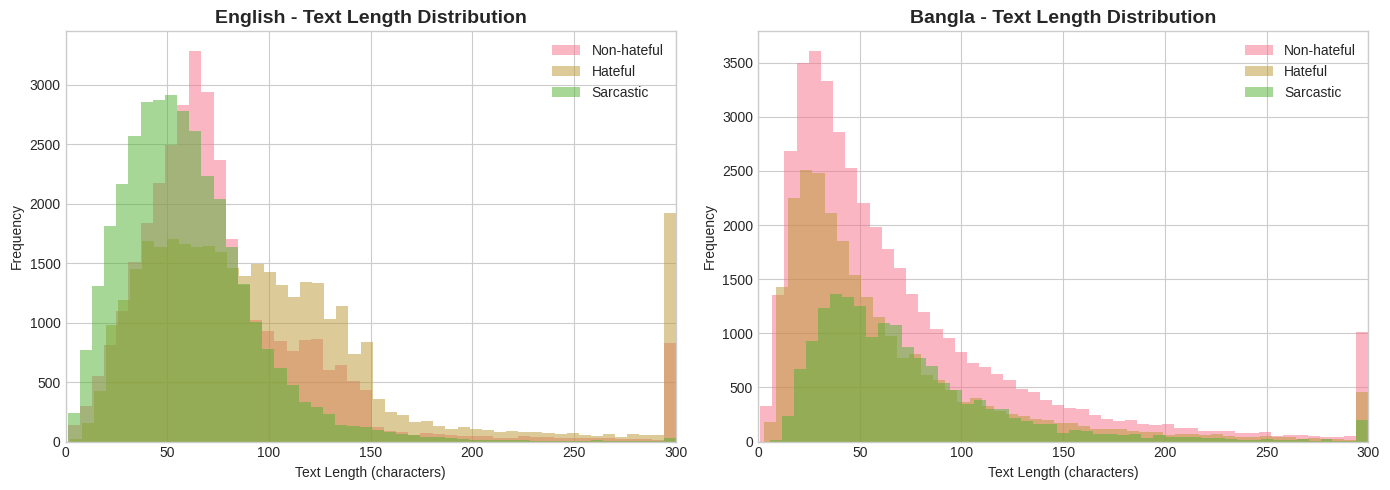

In [6]:
df_en['text_length'] = df_en['text'].str.len()
df_bn['text_length'] = df_bn['text'].str.len()
 
print("=" * 70)
print("ENGLISH TEXT LENGTH STATISTICS")
print("=" * 70)
en_stats = df_en.groupby('class')['text_length'].agg(['min', 'max', 'mean', 'median', 'std'])
en_stats.index = [f"{i} ({CLASS_NAMES[i]})" for i in en_stats.index]
print(en_stats.round(1).to_string())
 
print("\n" + "=" * 70)
print("BANGLA TEXT LENGTH STATISTICS")
print("=" * 70)
bn_stats = df_bn.groupby('label')['text_length'].agg(['min', 'max', 'mean', 'median', 'std'])
bn_stats.index = [f"{i} ({CLASS_NAMES[i]})" for i in bn_stats.index]
print(bn_stats.round(1).to_string())
 
# Plot text length distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
for cls in [0, 1, 2]:
    axes[0].hist(df_en[df_en['class']==cls]['text_length'].clip(upper=300),
                 bins=50, alpha=0.5, label=CLASS_NAMES[cls])
axes[0].set_title('English - Text Length Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Text Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].set_xlim(0, 300)
 
for cls in [0, 1, 2]:
    axes[1].hist(df_bn[df_bn['label']==cls]['text_length'].clip(upper=300),
                 bins=50, alpha=0.5, label=CLASS_NAMES[cls])
axes[1].set_title('Bangla - Text Length Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Text Length (characters)')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].set_xlim(0, 300)
 
plt.tight_layout()
plt.savefig('text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
def get_top_words(texts, n=50):
    """Get top n most frequent words from a series of texts."""
    all_words = []
    for text in texts.dropna():
        # Simple tokenization - split on whitespace and remove punctuation
        words = re.findall(r'\b\w+\b', str(text).lower())
        all_words.extend(words)
    return Counter(all_words).most_common(n)
 
# English stop words to optionally highlight (NOT remove)
en_stop_words = {'the', 'a', 'an', 'is', 'are', 'was', 'were', 'be', 'been',
                 'being', 'have', 'has', 'had', 'do', 'does', 'did', 'will',
                 'would', 'could', 'should', 'may', 'might', 'shall', 'can',
                 'to', 'of', 'in', 'for', 'on', 'with', 'at', 'by', 'from',
                 'it', 'this', 'that', 'these', 'those', 'i', 'you', 'he',
                 'she', 'we', 'they', 'me', 'him', 'her', 'us', 'them',
                 'my', 'your', 'his', 'its', 'our', 'their', 'and', 'or',
                 'but', 'not', 'no', 'if', 'so', 'as', 'up', 'out', 'just',
                 'get', 'got', 'like', 'rt', 'amp', 'http', 'https', 'co'}
 
print("=" * 70)
print("TOP 20 WORDS PER CLASS - ENGLISH (excluding common stop words)")
print("=" * 70)
 
for cls in [0, 1, 2]:
    texts = df_en[df_en['class']==cls]['text']
    top_words = get_top_words(texts, n=70)
    # Filter out stop words for display
    filtered = [(w, c) for w, c in top_words if w not in en_stop_words][:20]
    print(f"\nClass {cls} ({CLASS_NAMES[cls]}):")
    for i, (word, count) in enumerate(filtered, 1):
        print(f"  {i:2d}. {word:20s} ({count:,})")
 
print("\n" + "=" * 70)
print("TOP 20 WORDS PER CLASS - BANGLA")
print("=" * 70)
 
for cls in [0, 1, 2]:
    texts = df_bn[df_bn['label']==cls]['text']
    top_words = get_top_words(texts, n=20)
    print(f"\nLabel {cls} ({CLASS_NAMES[cls]}):")
    for i, (word, count) in enumerate(top_words, 1):
        print(f"  {i:2d}. {word:20s} ({count:,})")

TOP 20 WORDS PER CLASS - ENGLISH (excluding common stop words)

Class 0 (Non-hateful):
   1. s                    (7,042)
   2. t                    (5,135)
   3. xa0                  (3,834)
   4. mkr                  (3,667)
   5. n                    (2,489)
   6. what                 (2,030)
   7. about                (1,988)
   8. all                  (1,936)
   9. how                  (1,607)
  10. trump                (1,452)
  11. don                  (1,385)
  12. people               (1,351)
  13. one                  (1,327)
  14. who                  (1,291)
  15. m                    (1,252)
  16. more                 (1,180)
  17. when                 (1,134)
  18. why                  (1,118)
  19. there                (1,060)

Class 1 (Hateful):
   1. t                    (9,809)
   2. bitch                (9,740)
   3. fuck                 (5,905)
   4. s                    (5,450)
   5. all                  (3,941)
   6. bitches              (3,266)
   7. ass         

In [8]:
!apt-get install -y fonts-beng

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-beng-extra fonts-lohit-beng-assamese fonts-lohit-beng-bengali
The following NEW packages will be installed:
  fonts-beng fonts-beng-extra fonts-lohit-beng-assamese
  fonts-lohit-beng-bengali
0 upgraded, 4 newly installed, 0 to remove and 138 not upgraded.
Need to get 459 kB of archives.
After this operation, 1,025 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-beng-extra all 3.2.1-1 [323 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-lohit-beng-assamese all 2.91.5-2 [66.9 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-lohit-beng-bengali all 2.91.5-2 [66.9 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-beng all 2:1.3 [3,032 B]
Fetched 459 kB in 1s (643 kB/s)       
Selecting previously unselected package fonts-beng-extr

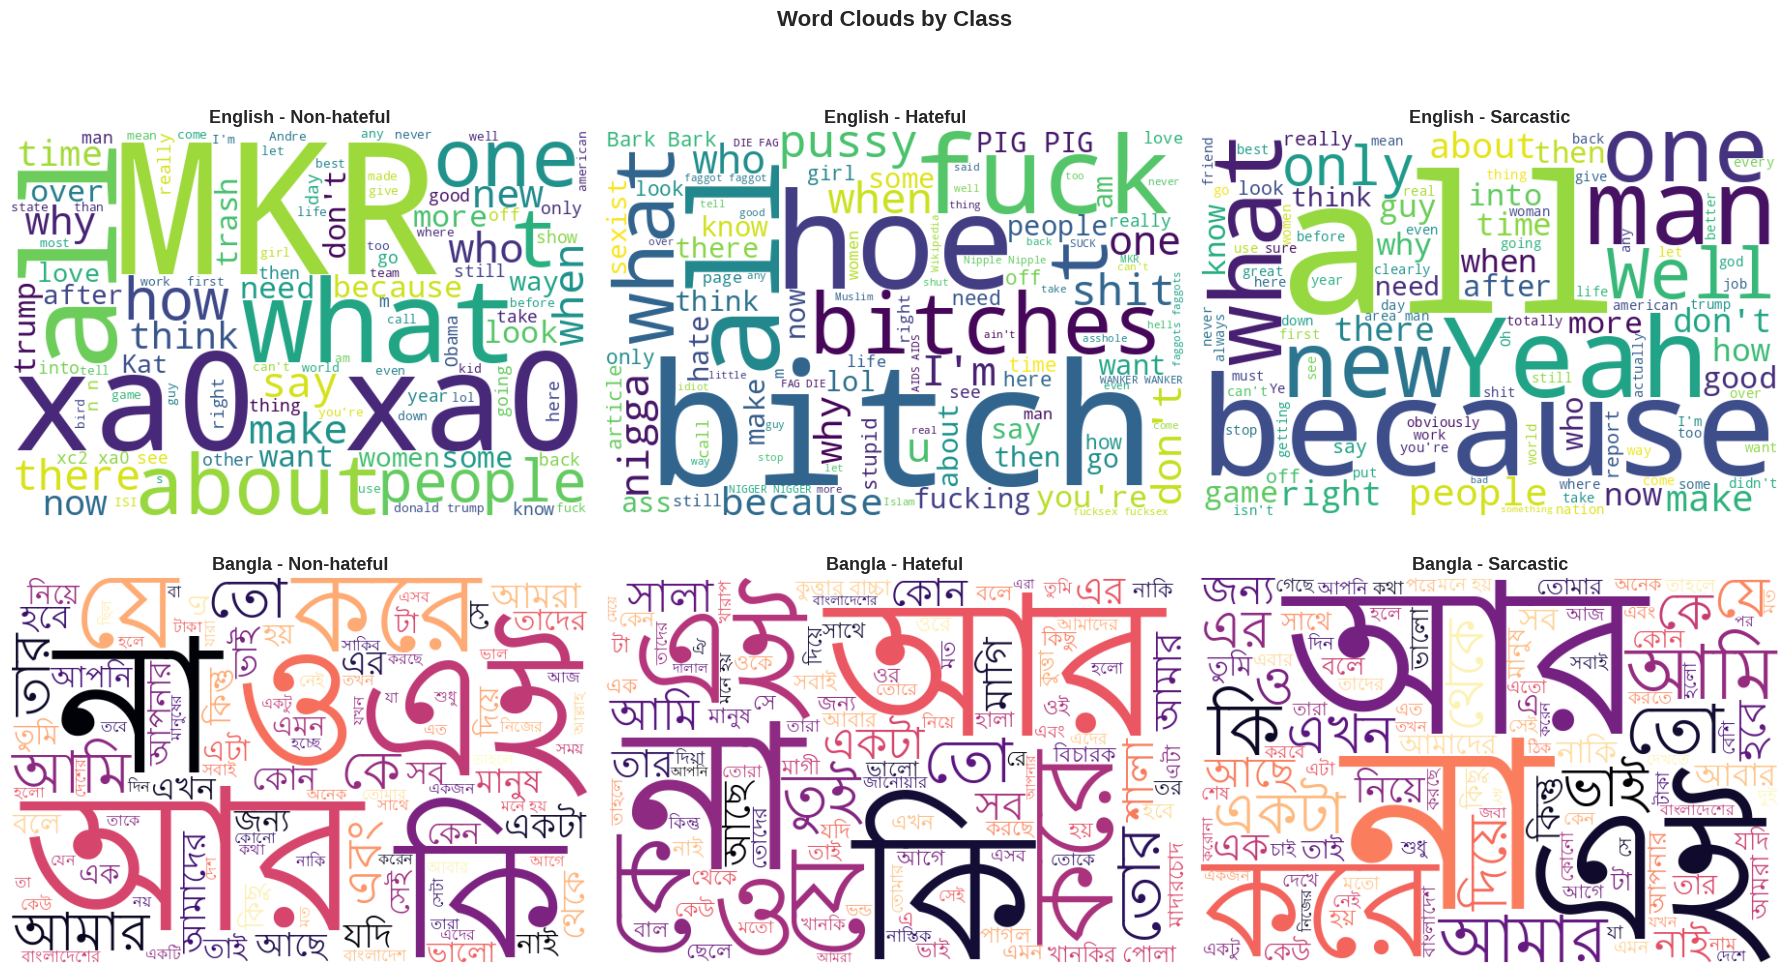

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
 
# English word clouds
for idx, cls in enumerate([0, 1, 2]):
    texts = df_en[df_en['class']==cls]['text']
    all_text = ' '.join(texts.dropna().tolist())
    wc = WordCloud(width=600, height=400, max_words=100,
                   background_color='white', colormap='viridis',
                   stopwords=en_stop_words).generate(all_text)
    axes[0][idx].imshow(wc, interpolation='bilinear')
    axes[0][idx].set_title(f'English - {CLASS_NAMES[cls]}', fontsize=13, fontweight='bold')
    axes[0][idx].axis('off')
 
# Bangla word clouds
for idx, cls in enumerate([0, 1, 2]):
    texts = df_bn[df_bn['label']==cls]['text']
    all_text = ' '.join(texts.dropna().tolist())
    
    # Update the font_path to point to the Lohit Bengali font
    bengali_font_path = '/usr/share/fonts/truetype/lohit-bengali/Lohit-Bengali.ttf'
    
# Add regexp=r"[\u0980-\u09FF]+" to force it to keep Bengali words together
    wc = WordCloud(width=600, height=400, max_words=100,
                   background_color='white', colormap='magma',
                   font_path=bengali_font_path,
                   regexp=r"[\u0980-\u09FF]+").generate(all_text)
                   
    axes[1][idx].imshow(wc, interpolation='bilinear')
    axes[1][idx].set_title(f'Bangla - {CLASS_NAMES[cls]}', fontsize=13, fontweight='bold')
    axes[1][idx].axis('off')
 
plt.suptitle('Word Clouds by Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('word_clouds.png', dpi=150, bbox_inches='tight')
plt.show()


BANGLA DATASET - SOURCE ANALYSIS

Total texts per source:
source
BD_SHS         50281
BenSarc        25636
BanglaSarc3     4008
BIDWESH         3061
ALERT           1006


Source x Label Crosstab:
             Non-hateful  Hateful  Sarcastic    All
source                                             
ALERT               1006        0          0   1006
BD_SHS             26125    24156          0  50281
BIDWESH             1548     1513          0   3061
BanglaSarc3            0        0       4008   4008
BenSarc            12818        0      12818  25636
All                41497    25669      16826  83992


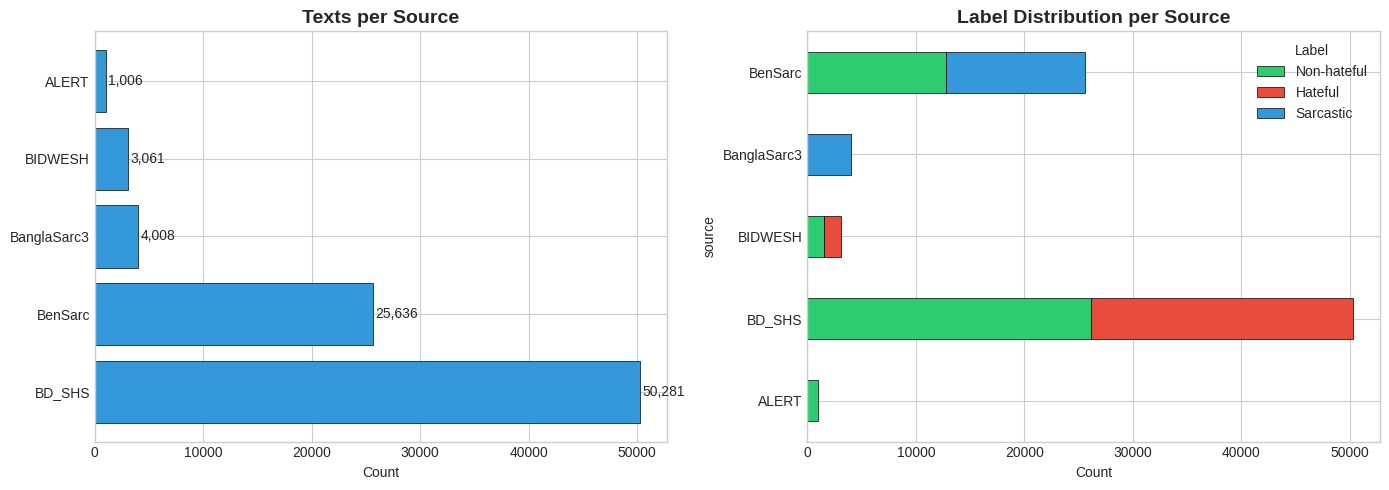


Key Findings:
- BD_SHS (50,281): Main source. Contains BOTH hateful (24K) and non-hateful (26K). NO sarcasm.
- BenSarc (25,636): Contains non-hateful (12.8K) and sarcastic (12.8K). NO hateful texts.
- BanglaSarc3 (4,008): ONLY sarcastic texts.
- BIDWESH (3,061): Mixed hateful (1.5K) and non-hateful (1.5K). NO sarcasm.
- ALERT (1,006): ONLY non-hateful texts.

Implication: Sarcastic texts come ONLY from BenSarc and BanglaSarc3.
Hateful texts come ONLY from BD_SHS and BIDWESH.
There is NO overlap - no source contains both hateful AND sarcastic texts.


In [12]:
print("=" * 70)
print("BANGLA DATASET - SOURCE ANALYSIS")
print("=" * 70)
 
# Source counts
print("\nTotal texts per source:")
print(df_bn['source'].value_counts().to_string())
 
# Source x Label crosstab
ct = pd.crosstab(df_bn['source'], df_bn['label'], margins=True)
ct.columns = [CLASS_NAMES.get(c, c) for c in ct.columns]
print("\n\nSource x Label Crosstab:")
print(ct.to_string())
 
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Source distribution
source_counts = df_bn['source'].value_counts()
axes[0].barh(source_counts.index, source_counts.values, color='#3498db', edgecolor='black', linewidth=0.5)
axes[0].set_title('Texts per Source', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Count')
for i, v in enumerate(source_counts.values):
    axes[0].text(v + 200, i, f'{v:,}', va='center')
 
# Stacked bar: Source x Label
ct_no_margin = pd.crosstab(df_bn['source'], df_bn['label'])
ct_no_margin.columns = [CLASS_NAMES[c] for c in ct_no_margin.columns]
ct_no_margin.plot(kind='barh', stacked=True, ax=axes[1],
                  color=['#2ecc71', '#e74c3c', '#3498db'], edgecolor='black', linewidth=0.5)
axes[1].set_title('Label Distribution per Source', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].legend(title='Label')
 
plt.tight_layout()
plt.savefig('bangla_source_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
 
print("\nKey Findings:")
print("- BD_SHS (50,281): Main source. Contains BOTH hateful (24K) and non-hateful (26K). NO sarcasm.")
print("- BenSarc (25,636): Contains non-hateful (12.8K) and sarcastic (12.8K). NO hateful texts.")
print("- BanglaSarc3 (4,008): ONLY sarcastic texts.")
print("- BIDWESH (3,061): Mixed hateful (1.5K) and non-hateful (1.5K). NO sarcasm.")
print("- ALERT (1,006): ONLY non-hateful texts.")
print("\nImplication: Sarcastic texts come ONLY from BenSarc and BanglaSarc3.")
print("Hateful texts come ONLY from BD_SHS and BIDWESH.")
print("There is NO overlap - no source contains both hateful AND sarcastic texts.")

In [13]:
print("=" * 70)
print("RANDOM SAMPLES FOR MANUAL INSPECTION")
print("=" * 70)
print("Read these carefully and note patterns you observe.")
print("Write your notes in a separate document.\n")
 
np.random.seed(42)
 
for cls in [0, 1, 2]:
    print(f"\n{'='*60}")
    print(f"ENGLISH - Class {cls} ({CLASS_NAMES[cls]}) - 15 Random Samples")
    print(f"{'='*60}")
    samples = df_en[df_en['class']==cls].sample(15)
    for i, (_, row) in enumerate(samples.iterrows(), 1):
        print(f"\n  [{i:2d}] {row['text'][:200]}")
 
print("\n\n" + "#" * 70)
 
for cls in [0, 1, 2]:
    print(f"\n{'='*60}")
    print(f"BANGLA - Label {cls} ({CLASS_NAMES[cls]}) - 15 Random Samples")
    print(f"{'='*60}")
    samples = df_bn[df_bn['label']==cls].sample(15)
    for i, (_, row) in enumerate(samples.iterrows(), 1):
        print(f"\n  [{i:2d}] [{row['source']}] {row['text'][:200]}")

RANDOM SAMPLES FOR MANUAL INSPECTION
Read these carefully and note patterns you observe.
Write your notes in a separate document.


ENGLISH - Class 0 (Non-hateful) - 15 Random Samples

  [ 1] democratic senators urge justice department leadership to protect robert mueller

  [ 2] trump campaign alumni start group focused on voter registration and fraud

  [ 3] It was incredibly fucking difficult to type that.

  [ 4] KFC biscuits trash now

  [ 5] Creamy potatoes #HelenaAndVikki, #TakingYouHome #MKR, #Yum

  [ 6] create the ultimate 'boomer cave' from your empty nest

  [ 7] thanks, , more fun stuff coming soon.

  [ 8] satyajit ray's apu trilogy premieres at moma, again

  [ 9] "@MiracleMan wishes my name was hot piece of ace\xa0\xa0@MiracleMan\xa0Who is this nate guy?"

  [10] International law enforcement operation disrupts Shylock banking malware - PCWorld: International law enforcem... http://t.co/XiZRs7ATWL

  [11] very relevant

  [12] jeb bush calls for crackdown on sanctuary c

In [15]:
print("=" * 70)
print("ADDITIONAL STATISTICS FOR THESIS")
print("=" * 70)
 
# Word count stats
df_en['word_count'] = df_en['text'].str.split().str.len()
df_bn['word_count'] = df_bn['text'].str.split().str.len()
 
print("\nENGLISH - Word Count per Class:")
print(df_en.groupby('class')['word_count'].agg(['mean', 'median', 'min', 'max']).round(1))
 
print("\nBANGLA - Word Count per Class:")
print(df_bn.groupby('label')['word_count'].agg(['mean', 'median', 'min', 'max']).round(1))
 
# Check for duplicates
en_dupes = df_en['text'].duplicated().sum()
bn_dupes = df_bn['text'].duplicated().sum()
print(f"\nDuplicate texts - English: {en_dupes:,} ({en_dupes/len(df_en)*100:.1f}%)")
print(f"Duplicate texts - Bangla: {bn_dupes:,} ({bn_dupes/len(df_bn)*100:.1f}%)")
 
# Very short texts (potential noise)
en_short = (df_en['text_length'] < 10).sum()
bn_short = (df_bn['text_length'] < 10).sum()
print(f"\nVery short texts (<10 chars) - English: {en_short}")
print(f"Very short texts (<10 chars) - Bangla: {bn_short}")
 
if en_short > 0:
    print("\nEnglish short text samples:")
    print(df_en[df_en['text_length'] < 10][['text', 'class']].head(10).to_string())
 
# Special character analysis
df_en['has_url'] = df_en['text'].str.contains(r'http[s]?://\S+', regex=True).astype(int)
df_en['has_mention'] = df_en['text'].str.contains(r'@\w+', regex=True).astype(int)
df_en['has_hashtag'] = df_en['text'].str.contains(r'#\w+', regex=True).astype(int)
df_en['has_caps'] = df_en['text'].str.contains(r'[A-Z]{3,}', regex=True).astype(int)
 
print("\nENGLISH - Special Character Prevalence:")
print(f"  Texts with URLs: {df_en['has_url'].sum():,} ({df_en['has_url'].mean()*100:.1f}%)")
print(f"  Texts with @mentions: {df_en['has_mention'].sum():,} ({df_en['has_mention'].mean()*100:.1f}%)")
print(f"  Texts with #hashtags: {df_en['has_hashtag'].sum():,} ({df_en['has_hashtag'].mean()*100:.1f}%)")
print(f"  Texts with CAPS (3+): {df_en['has_caps'].sum():,} ({df_en['has_caps'].mean()*100:.1f}%)")
 

ADDITIONAL STATISTICS FOR THESIS

ENGLISH - Word Count per Class:
       mean  median  min   max
class                         
0      15.2    11.0    1  2407
1      22.8    15.0    1  1403
2      10.2     9.0    1   150

BANGLA - Word Count per Class:
       mean  median  min  max
label                        
0      13.8     9.0    1  583
1      12.6     8.0    1  552
2      14.2    12.0    1  318

Duplicate texts - English: 0 (0.0%)
Duplicate texts - Bangla: 141 (0.2%)

Very short texts (<10 chars) - English: 888
Very short texts (<10 chars) - Bangla: 1154

English short text samples:
          text  class
77   Coin Flip      2
149  nasty hoe      1
209       Link      0
349     Exodia      2
427  Newsflash      2
529    Rule 6.      2
688    Agreed.      0
714  ah, okay.      0
939    OH NOES      0
949    Yeah...      0

ENGLISH - Special Character Prevalence:
  Texts with URLs: 3,188 (3.0%)
  Texts with @mentions: 14,662 (14.0%)
  Texts with #hashtags: 13,773 (13.2%)
  Texts with